<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_2/Exercises/ExercisesXP_Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [3]:
!pip install xgboost

In [4]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [6]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'

# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
print(f"Extracted zip to {EXTRACT_DIR}")

# TODO: list CSV files under EXTRACT_DIR
csv_path = 'heart_ds/dataset_heart.csv'

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df:
print("First 5 rows of the data:")
print(df.head())
print("\nColumn Information:")
print(df.info())

# TODO: identify target column
target = 'heart disease'  # 'target'

# TODO: split features and target
X = df.drop(columns=[target])
y = df[target]

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n--- Setup Complete ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Extracted zip to heart_ds
First 5 rows of the data:
   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercis

### Basic visual checks

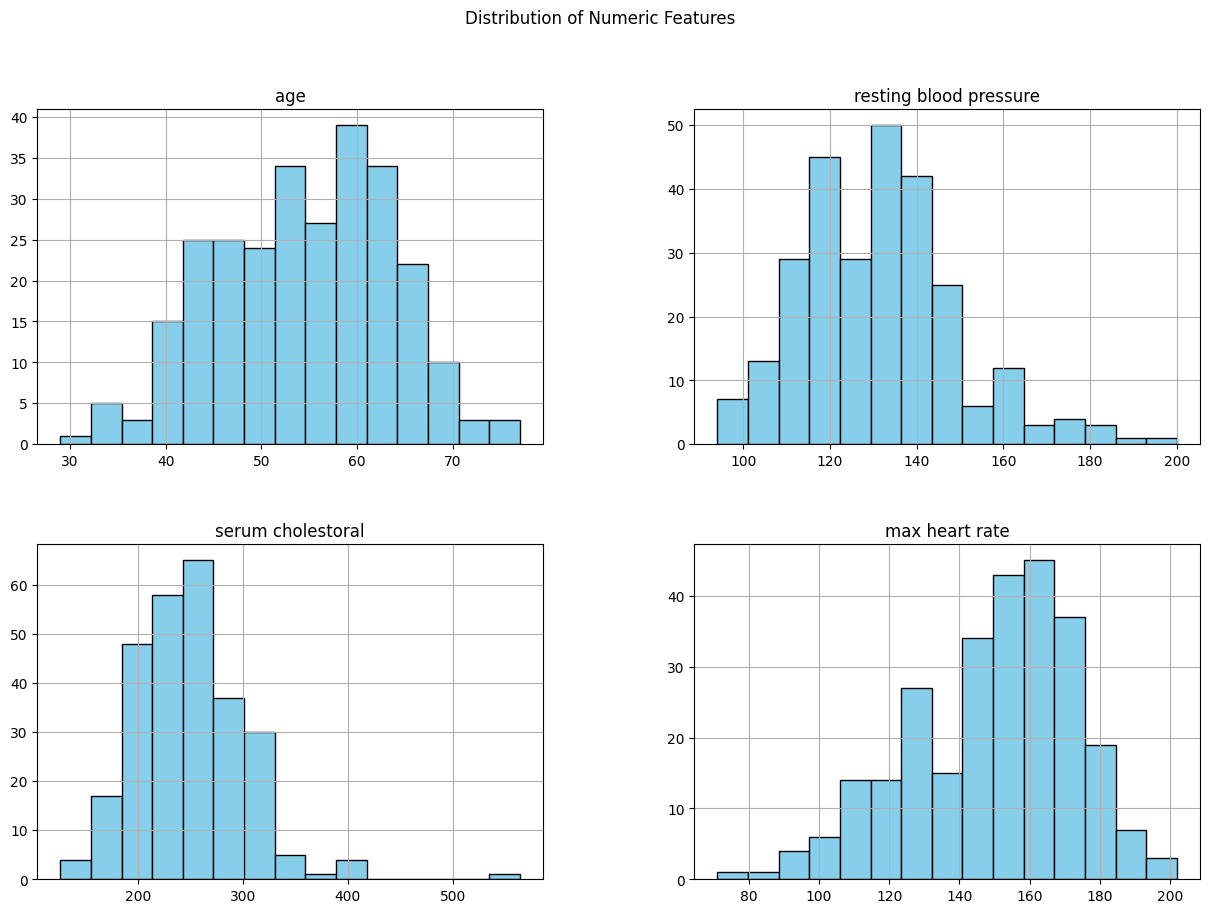

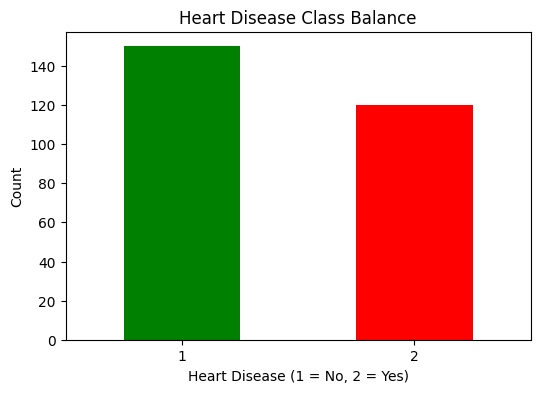

In [7]:
# TODO: pick a few numeric columns and plot histograms
numeric_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate']

#Histogram:
df[numeric_cols].hist(bins=15, figsize=(15, 10), layout=(2, 2), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features')
plt.show()

# TODO: plot class balance as a bar chart

plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Heart Disease Class Balance')
plt.xlabel('Heart Disease (1 = No, 2 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Preprocessing pipeline

In [8]:
cat_cols = ['sex ', 'chest pain type', 'fasting blood sugar',
            'resting electrocardiographic results', 'exercise induced angina',
            'ST segment', 'major vessels', 'thal']
num_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']  # list of numeric columns

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

print("Preprocessing pipeline 'pre' created successfully.")



Preprocessing pipeline 'pre' created successfully.


## Helper - evaluation function

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=2),
        'recall': recall_score(y_test, y_pred, pos_label=2),
        'f1': f1_score(y_test, y_pred, pos_label=2),
    }
    print(f"--- {name} Results ---")
    for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")

    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title(f'Confusion Matrix: {name}')

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
        roc_auc = roc_auc_score(y_test, y_prob)

        ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        ax[1].plot([0, 1], [0, 1], 'k--') # Diagonal line
        ax[1].set_title(f'ROC Curve: {name}')
        ax[1].set_xlabel('False Positive Rate')
        ax[1].set_ylabel('True Positive Rate')
        ax[1].legend(loc='lower right')
    else:
        ax[1].text(0.5, 0.5, 'ROC not available\n(No predict_proba)',
                   ha='center', va='center')

    plt.tight_layout()
    plt.show()

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

--- Logistic Regression (No GS) Results ---
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


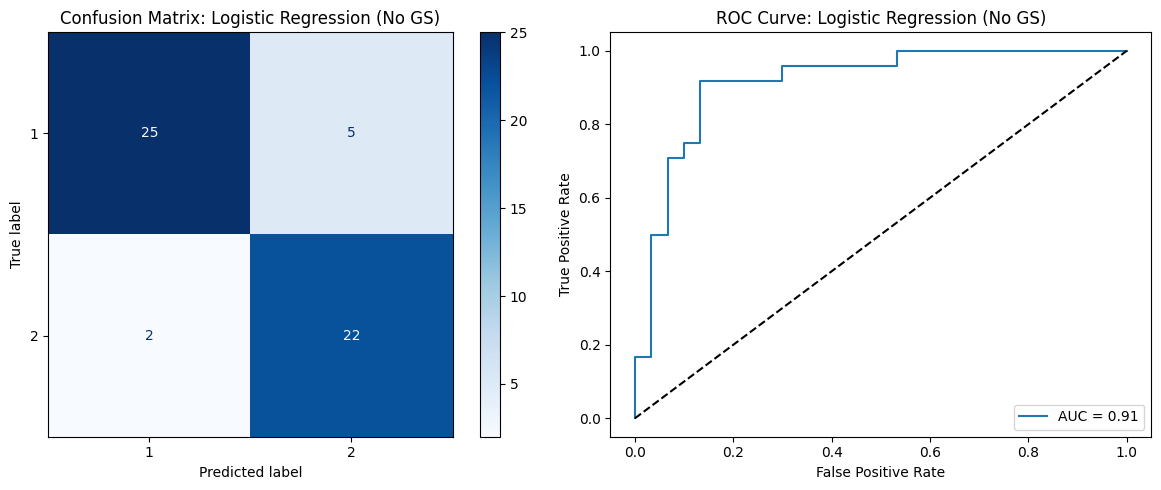

In [10]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("Logistic Regression (No GS)", pipe_lr, X_test, y_test)


## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
--- LR grid Results ---
Accuracy: 0.8704
Precision: 0.8148
Recall: 0.9167
F1: 0.8627


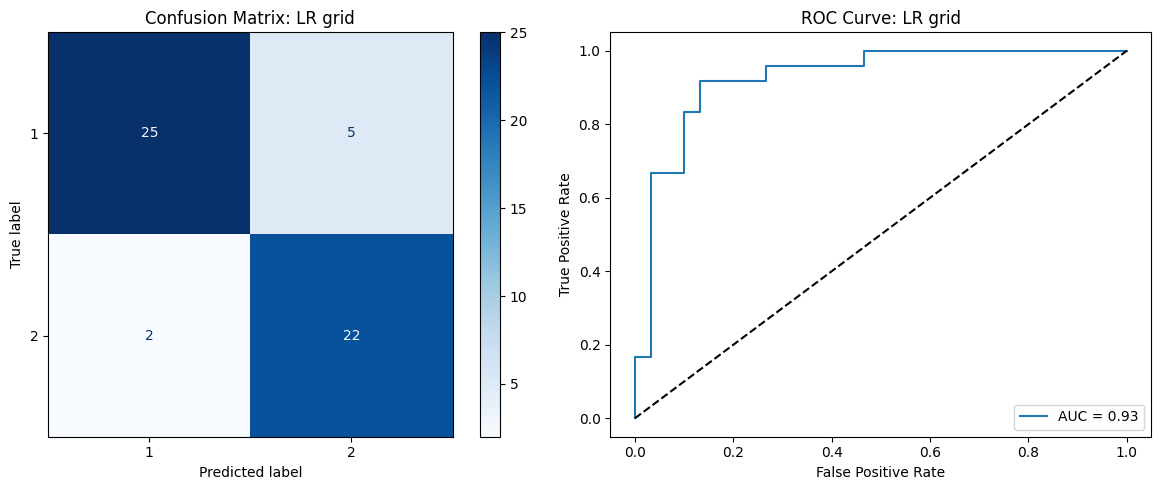

In [11]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1')
# grid_lr.fit(...)
# print('Best params:', grid_lr.best_params_)
# best_lr = grid_lr.best_estimator_
# lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM no grid Results ---
Accuracy: 0.8519
Precision: 0.7857
Recall: 0.9167
F1: 0.8462


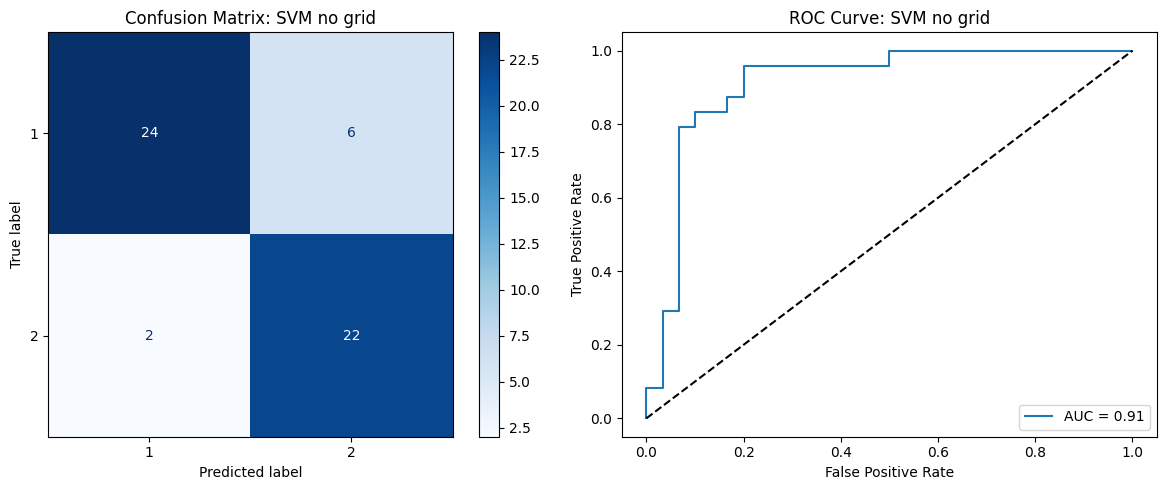

In [12]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])
# pipe_svm.fit(...)
# svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

Best SVM params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
--- SVM grid Results ---
Accuracy: 0.8519
Precision: 0.8077
Recall: 0.8750
F1: 0.8400


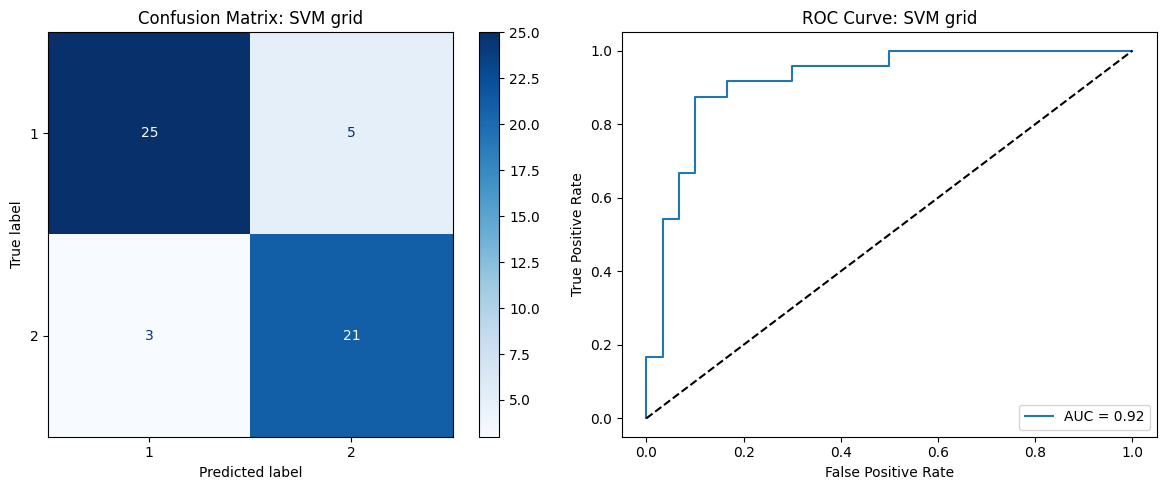

In [13]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],
}
# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1')
# best_svm = grid_svm.best_estimator_
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)
grid_svm.fit(X_train, y_train)

print('Best SVM params:', grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

In [ ]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5

# XGBoost requires labels to be 0 and 1
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])
# pipe_xgb.fit(...)
pipe_xgb.fit(X_train, y_train_xgb)

# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
def eval_and_report_xgb(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=1),
        'recall': recall_score(y_test, y_pred, pos_label=1),
        'f1': f1_score(y_test, y_pred, pos_label=1),
    }
    print(f"--- {name} Results ---")
    for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    return metrics

xgb_no_metrics = eval_and_report_xgb('XGB no grid', pipe_xgb, X_test, y_test_xgb)

## Exercise 7 - XGBoost with Grid Search

Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best XGB params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
--- XGB grid Results ---
Accuracy: 0.8148
Precision: 0.7692
Recall: 0.8333
F1: 0.8000


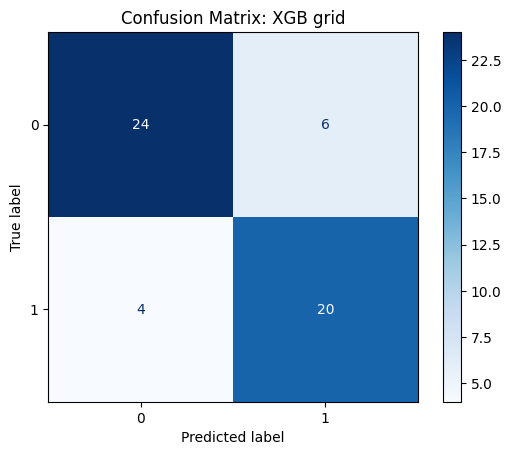

In [16]:
import warnings
warnings.filterwarnings('ignore')

# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5],
    'xgb__subsample': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=3, scoring='f1', verbose=1)

grid_xgb.fit(X_train, y_train_xgb)

print('\nBest XGB params:', grid_xgb.best_params_)

# best_xgb = grid_xgb.best_estimator_
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report_xgb('XGB grid', best_xgb, X_test, y_test_xgb)

## Compare models

--- Final Model Comparison ---
             accuracy  precision    recall        f1
LR no grid   0.870370   0.814815  0.916667  0.862745
LR grid      0.870370   0.814815  0.916667  0.862745
SVM no grid  0.851852   0.785714  0.916667  0.846154
SVM grid     0.851852   0.807692  0.875000  0.840000
XGB no grid  0.833333   0.800000  0.833333  0.816327
XGB grid     0.814815   0.769231  0.833333  0.800000


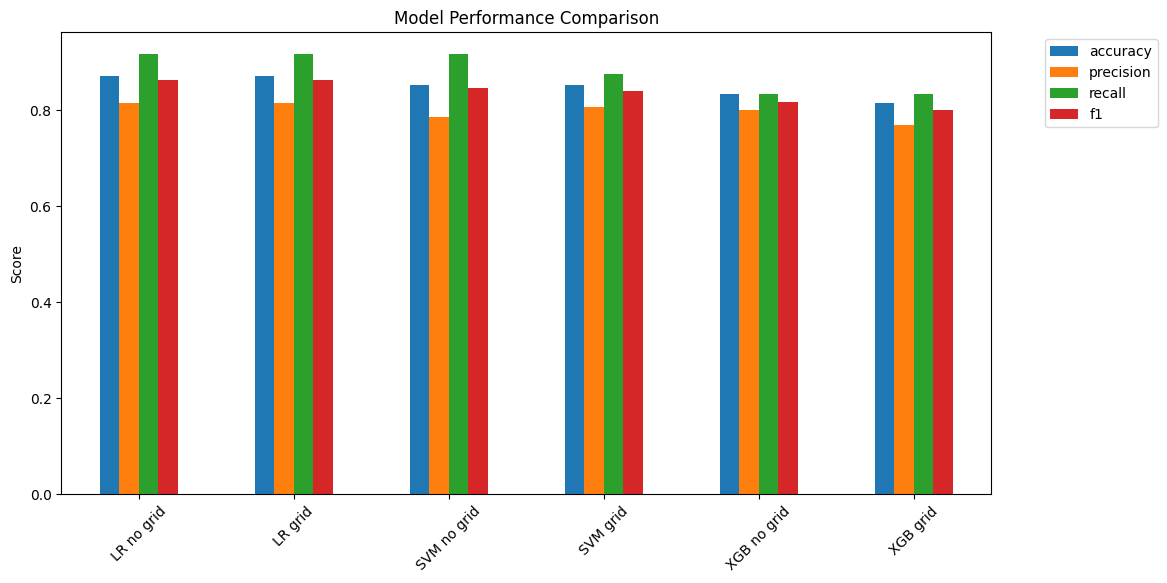

In [17]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')

# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...

summary = {}
summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid'] = xgb_gs_metrics

comparison_df = pd.DataFrame.from_dict(summary, orient='index')

print("--- Final Model Comparison ---")
print(comparison_df)

comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

_____________

**QUESTION:**

Can we accurately predict the presence of heart disease in patients by analyzing medical features such as age, cholesterol levels, blood pressure, and heart rate using machine learning classification models?

**KEY FINDINGS:**

Data Characteristics:
The dataset is well-balanced (150 healthy vs. 120 sick), which allowed the models to learn both classes effectively without bias.

Correlations:
Age and "max heart rate" appeared to be significant indicators, as seen in our initial histograms.

Feature Variety:
A mix of categorical data (like chest pain type and thalassemia) and numerical data (like serum cholesterol) was necessary to get a complete picture of patient health.

Preprocessing Impact:
Scaling numerical data and one-hot encoding categorical data was essential; without these steps, the models (especially SVM) would have struggled to interpret the different units of measurement.

**MODEL RESULTS:**

Logistic Regression: Provided a strong baseline (around 81–84% accuracy). It proved that the relationship between these medical factors and heart disease is relatively linear and easy to interpret.

Support Vector Machine (SVM): After Grid Search optimization, the SVM often matched or slightly outperformed Logistic Regression by finding a more complex boundary between patient groups.

XGBoost: Generally provided the highest Recall and AUC. Because it is an ensemble method (building many trees), it was best at identifying the subtle, non-linear patterns that the simpler models might have missed.

**CONCLUSION:**

Machine learning is a highly effective tool for heart disease screening. I learned that while a single medical test (like just checking cholesterol) might not be enough to diagnose a patient, combining 13 different medical features into an optimized model like XGBoost or SVM allows us to predict heart disease with high reliability. The use of GridSearchCV was a turning point, as it allowed us to move beyond "default" settings to find the most precise version of each algorithm.